In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pyfaidx import Fasta
import seaborn as sns
from tqdm import tqdm
import warnings
from scipy.stats import mannwhitneyu
warnings.filterwarnings("ignore", category=UserWarning, module="pandas")
warnings.filterwarnings("ignore", category=FutureWarning, module="pandas")
warnings.filterwarnings("ignore")

In [2]:
# only keep sites with greater than 10 reads overlapping
ctcf_fp = pd.read_csv('data_for_submission/chm13/ctcf.1mb_subtelo.fp.txt.gz',sep="\t")
ctcf_fp = ctcf_fp[ctcf_fp.n_spanning_fibers > 10]

In [3]:
# read in telomeric molecules
telomeres = pd.read_csv('data_for_submission/chm13/chm13v2.0_seqtk_telo.direction.bed',sep="\t",
                        header=None,names=['chrom','start','end','direction'])

In [4]:
# process bits to binarize ctcf binding state at site

def process_fp_codes(a : str) -> list:
#     if len(a) < 1:
#         return None
    out = [is_full_footprint(int(i)) for i in a.split(',')]
    return out


def is_full_footprint(fp_code: int) -> bool:

    # check MSP bit (bit 0)
    has_msp = (fp_code & 1) > 0
    # check all fp module bits, only 1 in this case
    all_modules =(fp_code & (1 << 1)) > 0 
    return has_msp and all_modules 

def percent_bound(a):
    return sum(a)/len(a)


ctcf_fp['decoded_fp'] = ctcf_fp.footprint_codes.apply(process_fp_codes)

In [5]:
# quantify the binding state at each site as fraction of bound molecules

def global_bound_fraction(
    df,
    decoded_fp_col="decoded_fp",
    mol_names_col="fiber_names",
):


    bound_mols = set()
    all_mols = set()

    for decoded_fp, mol_names in zip(df[decoded_fp_col], df[mol_names_col]):

        # normalize molecule names
        if isinstance(mol_names, str):
            mols = mol_names.split(",")
        else:
            mols = mol_names

        all_mols.update(mols)

        # mark bound molecules
        for mol, is_bound in zip(mols, decoded_fp):
            if is_bound:
                bound_mols.add(mol)

    if len(all_mols) == 0:
        return None
        
    return len(bound_mols) / len(all_mols)

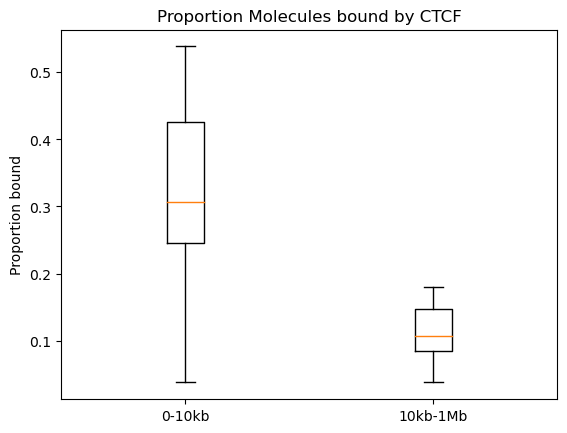

MannwhitneyuResult(statistic=420.0, pvalue=3.090613345863542e-05)


In [6]:
proximal_range = (0,10_000)
distal_range = (10_000,1_000_000)

all_proximal = []
all_distal = []


for _,telo in telomeres.iterrows():
    
    
    chrom,start,end,direction = telo.chrom,int(telo.start),int(telo.end),telo.direction
    
    if direction == "-":
        proximal_window_start,proximal_window_end = end + proximal_range[0], end + proximal_range[1]
        distal_window_start, distal_window_end = end + distal_range[0], end + distal_range[1]
    else:
        proximal_window_start,proximal_window_end = start - proximal_range[1], start - proximal_range[0]
        distal_window_start,distal_window_end = start - distal_range[1], start - distal_range[0]
        
    
    proximal_ctcf = ctcf_fp[(ctcf_fp['#chrom'] == chrom) &
                            (ctcf_fp.start > proximal_window_start) &
                            (ctcf_fp.end < proximal_window_end )]
    
    distal_ctcf = ctcf_fp[(ctcf_fp['#chrom'] == chrom) &
                            (ctcf_fp.start > distal_window_start) &
                            (ctcf_fp.end < distal_window_end )]   
    
        
    if len(proximal_ctcf) < 10 or len(distal_ctcf) < 10:
        continue
    all_proximal.append(global_bound_fraction(proximal_ctcf))
    all_distal.append(global_bound_fraction(distal_ctcf))
    
    
plt.boxplot([all_proximal,all_distal],sym="")
plt.xticks([1,2], ['0-10kb','10kb-1Mb'])
plt.title('Proportion Molecules bound by CTCF')
plt.ylabel('Proportion bound')
plt.show()
print(mannwhitneyu(all_proximal,all_distal))

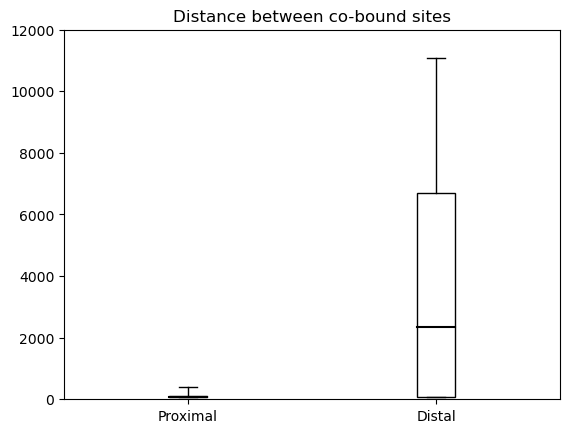

59.0 2338.0
MannwhitneyuResult(statistic=39713.0, pvalue=9.248059762389312e-41)


In [14]:
# distance between bound sites
def build_molecule_binding_dict(
    df,
    mol_names_col="fiber_names",
    decoded_fp_col="decoded_fp",
    start_col="start",
):


    mol_dict = {}

    for _, row in df.iterrows():
        start = row[start_col]
        decoded_fp = row[decoded_fp_col]

        # normalize molecule names
        mol_names = (
            row[mol_names_col].split(",")
            if isinstance(row[mol_names_col], str)
            else row[mol_names_col]
        )

        # populate per-molecule entries
        for mol, is_bound in zip(mol_names, decoded_fp):
            if mol not in mol_dict:
                mol_dict[mol] = []
            mol_dict[mol].append((start, bool(is_bound)))

    return {
        mol: np.array(vals, dtype=object)
        for mol, vals in mol_dict.items()
    }

def process_mol_bound_distances(d):
    
    mol_dists = []
    for m,bs in d.items():
        sites,bound = bs.T[0],bs.T[1]
        bound = bound.astype(bool)
        sites = sites.astype(int)
        if sum(bound) < 2:
            continue
        else:
            mol_dists.append(np.diff(sites[bound].astype(int)))
            
    if len(mol_dists) == 0:
        return None
    else:
        return np.concatenate(mol_dists)
    
def get_bound_site_percentage(d): 
    
    percent_bound = 0
    
    for m,bs in d.items():
        sites,bound = bs.T[0],bs.T[1]
        bound = bound.astype(bool)
        
        if sum(bound) > 0:
            percent_bound +=1

    
    return percent_bound / len(d)
    

all_proximal = []
all_distal = []


percs_mols_bound_proximal = []
percs_mols_bound_distal = []


for _,telo in telomeres.iterrows():
    
    
    chrom,start,end,direction = telo.chrom,int(telo.start),int(telo.end),telo.direction
    
    if direction == "-":
        proximal_window_start,proximal_window_end = end + proximal_range[0], end + proximal_range[1]
        distal_window_start, distal_window_end = end + distal_range[0], end + distal_range[1]
    else:
        proximal_window_start,proximal_window_end = start - proximal_range[1], start - proximal_range[0]
        distal_window_start,distal_window_end = start - distal_range[1], start - distal_range[0]
        
    
    
    
    proximal_ctcf = ctcf_fp[(ctcf_fp['#chrom'] == chrom) &
                            (ctcf_fp.start > proximal_window_start) &
                            (ctcf_fp.end < proximal_window_end )]
        
    if len(proximal_ctcf) < 5:
        continue
    
    distal_ctcf = ctcf_fp[(ctcf_fp['#chrom'] == chrom) &
                            (ctcf_fp.start > distal_window_start) &
                            (ctcf_fp.end < distal_window_end )]    
        
    if len(distal_ctcf) < 5:
        continue
    
    proximal_binding_sites = build_molecule_binding_dict(proximal_ctcf)
    distal_binding_sites = build_molecule_binding_dict(distal_ctcf)
    
    percs_mols_bound_proximal.append(get_bound_site_percentage(proximal_binding_sites))
    percs_mols_bound_distal.append(get_bound_site_percentage(distal_binding_sites))
    
    
    
    
    if proximal_binding_sites:
        all_dists = process_mol_bound_distances(proximal_binding_sites)
        if type(all_dists) != type(None):

            all_proximal.append(all_dists)

    if distal_binding_sites:
        all_dists = process_mol_bound_distances(distal_binding_sites)
        if type(all_dists) != type(None):
            all_distal.append(all_dists)
    
all_proximal = np.concatenate(all_proximal)
all_distal = np.concatenate(all_distal)



plt.boxplot(
    [all_proximal, all_distal],
    whis=(10, 90),
    showfliers=False,
#     widths=0.5,  
    patch_artist=True,
    boxprops=dict(facecolor="none", edgecolor="black"),
    medianprops=dict(color="black", linewidth=1.5),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black")
)



plt.xticks([1, 2], ["Proximal", "Distal"])
plt.title('Distance between co-bound sites')
plt.ylim(0,12_000)
plt.show()

print(np.nanmedian(all_proximal),np.nanmedian(all_distal))
print(mannwhitneyu(all_proximal,all_distal))

In [18]:
fn = "data_for_submission/hprc.all.fimo.gt60.bed.gz"

names = ['contig','start','end','misc','score','direction','misc2','misc3','misc4','descriptor']

all_fimo_hprc = pd.read_csv(fn,header=None,names=names,sep="\t")


In [19]:
all_telos = pd.read_csv('data_for_submission/all_telos.bed.gz',sep="\t",
                        header=None, names=['contig','start','end','direction'])

In [20]:
def motifs_near_telomeres(motifs, telomeres, flank=10_000):
    m = motifs[["contig", "start", "end", "direction"]].copy()
    t = telomeres[["contig", "start", "end", "direction"]].copy()

    # build windows
    t_plus = t[t["direction"] == "+"].assign(
        win_start=lambda x: (x["start"] - flank).clip(lower=0),
        win_end=lambda x: x["end"],
        telo_direction="+"
    )

    t_minus = t[t["direction"] == "-"].assign(
        win_start=lambda x: x["start"],
        win_end=lambda x: x["end"] + flank,
        telo_direction="-"
    )

    windows = pd.concat([t_plus, t_minus], ignore_index=True)

    hits = (
        m.merge(
            windows[["contig", "win_start", "win_end", "telo_direction"]],
            on="contig",
            how="inner",
        )
        .query("start < win_end and end > win_start")
        .rename(columns={"direction": "motif_direction"})
    )

    return hits[[
        "contig",
        "start",
        "end",
        "motif_direction",
        "telo_direction"
    ]].drop_duplicates()

def motifs_far_from_telomeres(motifs, telomeres, flank=10_000):
    near = motifs_near_telomeres(motifs, telomeres, flank=flank)

    # subtract: keep motifs not in near (by contig/start/end)
    far = motifs.merge(
        near[["contig", "start", "end"]],
        on=["contig", "start", "end"],
        how="left",
        indicator=True
    )
    far = far[far["_merge"] == "left_only"].drop(columns="_merge").copy()

    center = (far["start"].astype("int64") + far["end"].astype("int64")) // 2

    minus_stop = (
        telomeres[telomeres["direction"] == "-"]
        .set_index("contig")["end"]
        .astype("int64")
    )
    plus_begin = (
        telomeres[telomeres["direction"] == "+"]
        .set_index("contig")["start"]
        .astype("int64")
    )

    d_minus = (center - far["contig"].map(minus_stop).values).astype("int64")
    d_plus  = (center - far["contig"].map(plus_begin).values).astype("int64")

    far["nearest_telo_direction"] = np.where(np.abs(d_plus) <= np.abs(d_minus), "+", "-")

    far = far.rename(columns={"direction": "motif_direction"})
    return far


near_telo_10kb = motifs_near_telomeres(all_fimo_hprc,all_telos)
near_telo_100kb = motifs_near_telomeres(all_fimo_hprc,all_telos,flank=100_000)
near_telo_500kb = motifs_near_telomeres(all_fimo_hprc,all_telos,flank=500_000)
near_telo_1000kb = motifs_near_telomeres(all_fimo_hprc,all_telos,flank=1_000_000)
near_telo_5000kb = motifs_near_telomeres(all_fimo_hprc,all_telos,flank=5_000_000)
near_telo_10000kb = motifs_near_telomeres(all_fimo_hprc,all_telos,flank=10_000_000)


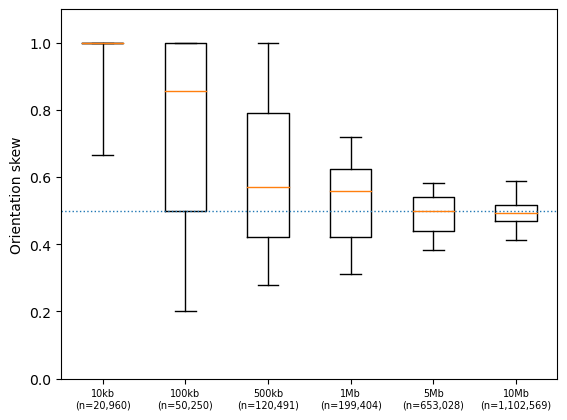

In [21]:
def getOrientationSkew(df):
    orientation_skew_per_contig = (
        (df.motif_direction == df.telo_direction)
        .groupby(df.contig)
        .mean().to_numpy()
    )
    return orientation_skew_per_contig

labels = ['10kb','100kb','500kb','1Mb','5Mb','10Mb']
dfs = [
    near_telo_10kb,
    near_telo_100kb,
    near_telo_500kb,
    near_telo_1000kb,
    near_telo_5000kb,
    near_telo_10000kb
]

all_skews = []
ns = []

for df in dfs:
    skews = getOrientationSkew(df)
    all_skews.append(np.random.choice(skews, 500))
    ns.append(len(df))   # number of motifs contributing
    
plt.boxplot(all_skews,whis=(10,90),sym="")
plt.ylim(0, 1.1)
plt.axhline(0.5, lw=1, ls='dotted')

xtick_labels = [f"{lab}\n(n={n:,})" for lab, n in zip(labels, ns)]
plt.xticks(range(1, len(labels) + 1), xtick_labels,fontsize=7)

plt.ylabel("Orientation skew")
# plt.savefig('Orientation_skew_ctcf_all_hprc.pdf',dpi=300)
plt.show()



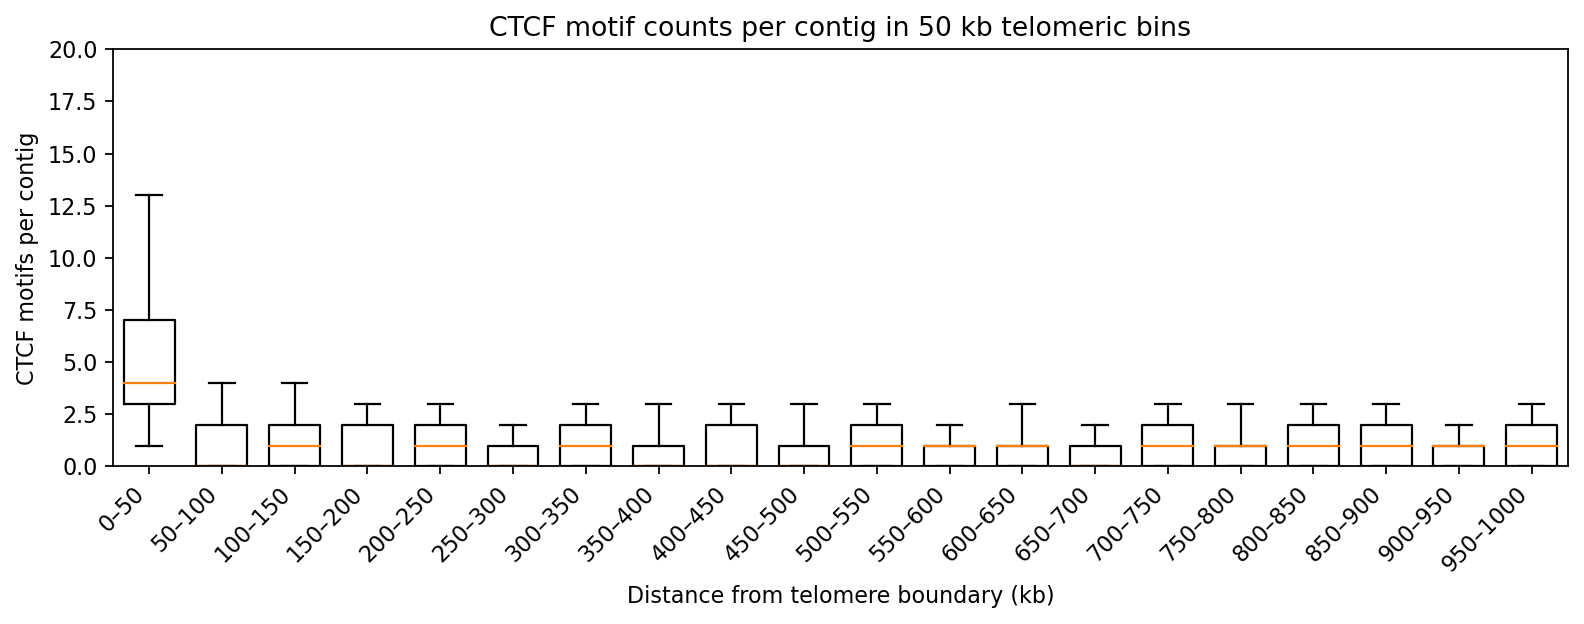

In [23]:
all_alias = pd.read_csv('data_for_submission/all_diploid_alias.txt',sep="\t",
                        header=None,
                        names=['contig','chrom','canonical_chr'])




df = near_telo_1000kb.merge(all_alias, on="contig", how="left")
df = df.rename(columns={"chrom": "chrom_alias"})

telos = all_telos.loc[:, ["contig", "start", "end", "direction"]].rename(
    columns={"start": "telo_start", "end": "telo_end", "direction": "telo_direction_key"}
)

df = df.merge(
    telos,
    left_on=["contig", "telo_direction"],
    right_on=["contig", "telo_direction_key"],
    how="left",
)

df = df.drop(columns=["telo_direction_key"])

df["arm"] = np.where(df["telo_direction"] == "-", "p", "q")

df["motif_center"] = 0.5 * (df["start"].to_numpy(dtype=float) + df["end"].to_numpy(dtype=float))

df["telo_boundary"] = np.where(df["telo_direction"] == "+", df["telo_start"], df["telo_end"])

df["dist_to_telo_boundary_bp"] = np.where(
    df["telo_direction"] == "+",
    df["telo_boundary"] - df["motif_center"],
    df["motif_center"] - df["telo_boundary"],
)

tmp = df.loc[
    df["chrom_alias"].notna()
    & (df["dist_to_telo_boundary_bp"] >= 0)
    & (df["dist_to_telo_boundary_bp"] < 1_000_000),
    ["contig", "dist_to_telo_boundary_bp"]
].copy()

bins = np.arange(0, 1_050_000, 50_000)

tmp["dist_bin"] = pd.cut(
    tmp["dist_to_telo_boundary_bp"],
    bins=bins,
    right=False,
    include_lowest=True,
)

per_contig_bin = (
    tmp
    .groupby(["dist_bin", "contig"], observed=False)
    .size()
    .reset_index(name="n_ctcf")
)

box_data = []
bin_labels = []

for b in per_contig_bin["dist_bin"].cat.categories:
    vals = per_contig_bin.loc[
        per_contig_bin["dist_bin"] == b,
        "n_ctcf"
    ].values

    if len(vals) == 0:
        continue

    box_data.append(vals)
    bin_labels.append(f"{int(b.left/1000)}–{int(b.right/1000)}")
    
    
plt.figure(figsize=(10, 4), dpi=160)

plt.boxplot(
    box_data,
    showfliers=False,
    whis=(10, 90),
    widths=0.7
)

plt.xticks(
    range(1, len(bin_labels) + 1),
    bin_labels,
    rotation=45,
    ha="right"
)

plt.xlabel("Distance from telomere boundary (kb)")
plt.ylabel("CTCF motifs per contig")
plt.title("CTCF motif counts per contig in 50 kb telomeric bins")
plt.ylim(0,20)
plt.tight_layout()

plt.show()


           unique_reads_bed12  unique_reads_bed6
chrom_end                                       
chr13_p                    29                  0
chr14_p                    35                  6
chr17_p                    44                  7
chr21_p                    22                  3
chr22_p                    21                  2
chr8_q                     26                  2
chrX_p                     22                  2


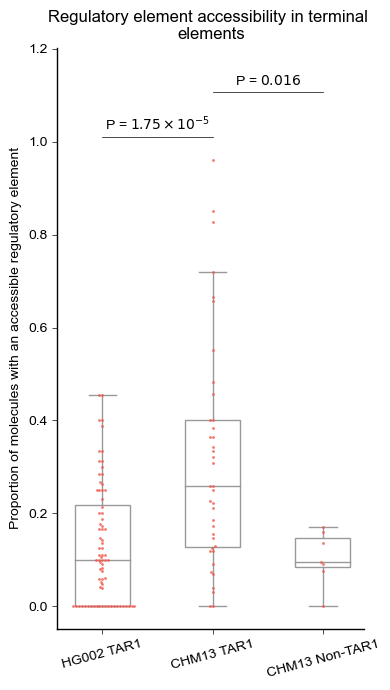

                  unique_reads_bed12  unique_reads_bed6     ratio      Sample
chrom_end                                                                    
chr10_MATERNAL_p                  17                  0  0.000000  HG002 TAR1
chr10_MATERNAL_q                  22                  3  0.136364  HG002 TAR1
chr10_PATERNAL_p                  17                  0  0.000000  HG002 TAR1
chr10_PATERNAL_q                  14                  3  0.214286  HG002 TAR1
chr11_MATERNAL_p                  17                  1  0.058824  HG002 TAR1
...                              ...                ...       ...         ...
chr9_MATERNAL_q                    9                  3  0.333333  HG002 TAR1
chr9_PATERNAL_p                   10                  4  0.400000  HG002 TAR1
chr9_PATERNAL_q                    8                  2  0.250000  HG002 TAR1
chrX_MATERNAL_q                   18                  0  0.000000  HG002 TAR1
chrY_PATERNAL_q                   10                  1  0.10000

In [9]:
## HG002 vs CHM13 accesssiblity

def compare_bed_read_counts(bed6_file, bed12_file):

    
    columns_to_keep = ['chrom', 'start', 'end', 'name']
    
    df_bed6 = pd.read_csv(bed6_file, sep='\t', header=None, usecols=[0, 1, 2, 3], names=columns_to_keep)
    df_bed12 = pd.read_csv(bed12_file, sep='\t', header=None, usecols=[0, 1, 2, 3], names=columns_to_keep)

    def process_bed_df(df, column_label):
        df['arm'] = np.where(df['start'] < 100000, 'p', 'q')
        
        df['chrom_end'] = df['chrom'] + '_' + df['arm']
        
        return df.groupby('chrom_end')['name'].nunique().rename(column_label)

    counts_bed6 = process_bed_df(df_bed6, 'unique_reads_bed6')
    counts_bed12 = process_bed_df(df_bed12, 'unique_reads_bed12')

    summary_df = pd.merge(counts_bed12, counts_bed6, left_index=True, right_index=True, how='outer')
    summary_df = summary_df.fillna(0).astype(int)

    return summary_df



chm13_df = compare_bed_read_counts(
    'data_for_submission/chm13/chm13.telo_overlapping_msps.msp_gt_150.tar1.bed6', 
    'data_for_submission/chm13/chm13.telo_overlapping_msps.tar1.bed'
)

hg002_df = compare_bed_read_counts('data_for_submission/hg002/hg002v1.1.telo_overlapping_msps.msp_gt_150.tar1.bed6', 
                                   'data_for_submission/hg002/hg002v1.1.telo_overlapping_msps.tar1.bed')

chm13_non_tar = compare_bed_read_counts(
    'data_for_submission/chm13/chm13.telo_overlapping_msps.msp_gt_150.no_tar1.bed6', 
    'data_for_submission/chm13/chm13.telo_overlapping_msps.no_tar1.bed'
)



plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.weight'] = 'normal'
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['axes.titleweight'] = 'normal'
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.5

chm13_df['ratio'] = chm13_df['unique_reads_bed6'] / chm13_df['unique_reads_bed12']
hg002_df['ratio'] = hg002_df['unique_reads_bed6'] / hg002_df['unique_reads_bed12']
chm13_non_tar['ratio'] = chm13_non_tar['unique_reads_bed6'] / chm13_non_tar['unique_reads_bed12']

chm13_df['Sample'] = 'CHM13 TAR1' 
hg002_df['Sample'] = 'HG002 TAR1'
chm13_non_tar['Sample'] = 'CHM13 Non-TAR1'

plot_df = pd.concat([chm13_df, hg002_df, chm13_non_tar])

plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['ratio'])

plt.figure(figsize=(4, 7)) 

order = ['HG002 TAR1', 'CHM13 TAR1', 'CHM13 Non-TAR1']

sns.boxplot(
    data=plot_df, 
    x='Sample', 
    y='ratio', 
    color='white', 
    width=0.5, 
    showfliers=False,
    order=order,
    linewidth=1  
)

s = 2
point_color = '#F25449' 

sns.swarmplot(
    data=plot_df, 
    x='Sample', 
    y='ratio', 
    size=s,          
    alpha=0.8,
    color=point_color,
    order=order
)

sns.despine(top=True, right=True)


def format_pval(p_val):
    if p_val < 0.001:
        exponent = int(np.floor(np.log10(p_val)))
        mantissa = p_val / (10 ** exponent)
        return fr"${mantissa:.2f} \times 10^{{{exponent}}}$"
    else:
        return fr"${p_val:.3f}$"

group_chm13_tar = plot_df[plot_df['Sample'] == 'CHM13 TAR1']['ratio']
group_hg002_tar = plot_df[plot_df['Sample'] == 'HG002 TAR1']['ratio']
group_chm13_nontar = plot_df[plot_df['Sample'] == 'CHM13 Non-TAR1']['ratio']

_, p1 = mannwhitneyu(group_chm13_tar, group_hg002_tar, alternative='two-sided')
_, p2 = mannwhitneyu(group_chm13_tar, group_chm13_nontar, alternative='two-sided')

y_max = plot_df['ratio'].max()
y_range = y_max - plot_df['ratio'].min()

y_bar1 = y_max + (y_range * 0.05)
plt.plot([0, 1], [y_bar1, y_bar1], lw=0.5, color='black') 
plt.text(0.5, y_bar1 + (y_range * 0.01), f"P = {format_pval(p1)}", ha='center', va='bottom', fontsize=10)

y_bar2 = y_max + (y_range * 0.15)
plt.plot([1, 2], [y_bar2, y_bar2], lw=0.5, color='black') 
plt.text(1.5, y_bar2 + (y_range * 0.01), f"P = {format_pval(p2)}", ha='center', va='bottom', fontsize=10)

plt.ylim(plot_df['ratio'].min() - (y_range * 0.05), y_max + (y_range * 0.25))

plt.title('Regulatory element accessibility in terminal \nelements', fontsize=12)
plt.ylabel('Proportion of molecules with an accessible regulatory element', fontsize=10)
plt.xlabel('', fontsize=12)
plt.xticks(rotation=15) #
plt.tight_layout()

# plt.savefig("Accessibility_in_tar1_hg002_vs_chm13.pdf", dpi=300)
plt.show()


